# A. Data Loading and Initial Exploration. #

In [1]:
#-- Import Pandas and Numpy Library. --#
import numpy as np
import pandas as pd
#-- Import .csv File. --#
titanic = pd.read_csv('Titanic_Dataset.csv')
#-- Print the Dataset. --#
titanic #-- Can use print(titanic). --#

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


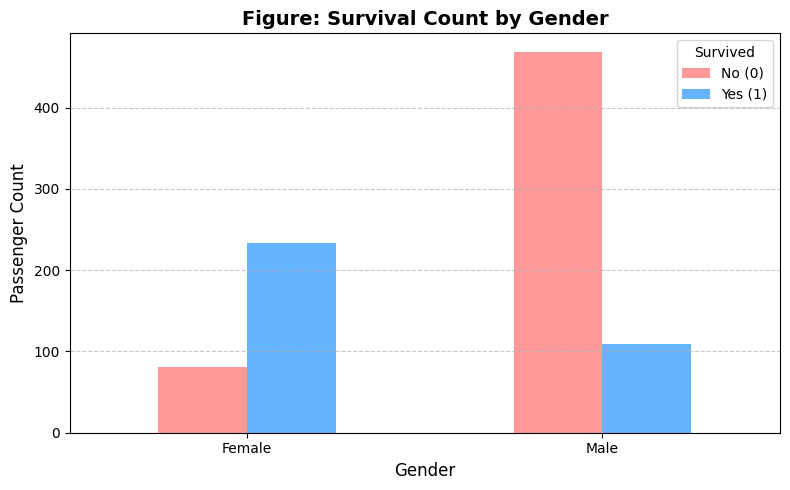

In [4]:
#-- In Drawing Graph Part, relationship between Sex(X) and Survived(Y). --#
#-- Import Python Library. --#
import matplotlib.pyplot as plt
#-- Group the Dataset by Sex(Gender-X) and Survived(Y). --#
#-- Then, pivot the table for plotting. --#
survival_counts = titanic.groupby(['Sex','Survived']).size().unstack()
#-- Generate bar chart. --#
ax = survival_counts.plot(kind='bar', figsize=(8, 5), color=['#ff9999', '#66b3ff'])
plt.title('Figure: Survival Count by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
#-- Customize legend, ticks, and background grid for better readability. --#
plt.legend(['No (0)', 'Yes (1)'], title='Survived')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
#-- Display the generated graph. --#
plt.tight_layout()
plt.show()

# B. Extended Exploratory Data Analysis. #

## 2.1 Passenger Class and Survival. ##
Purpose: Investigate whether passenger class influenced survival outcomes.

In [12]:
#-- Import Python Library. --#
import matplotlib.pyplot as plt
#-- # 1. Create a cross-tabulation table between Pclass and Survived. --#
survival_by_class = pd.crosstab(
    titanic['Pclass'],
    titanic['Survived']
)
survival_by_class
#-- Outcomes: The program returns number of survived (1) is 136 people and 80 note survived (1) which similarly with secodn and third class. --#



Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Text(0.5, 1.0, 'Third Class')

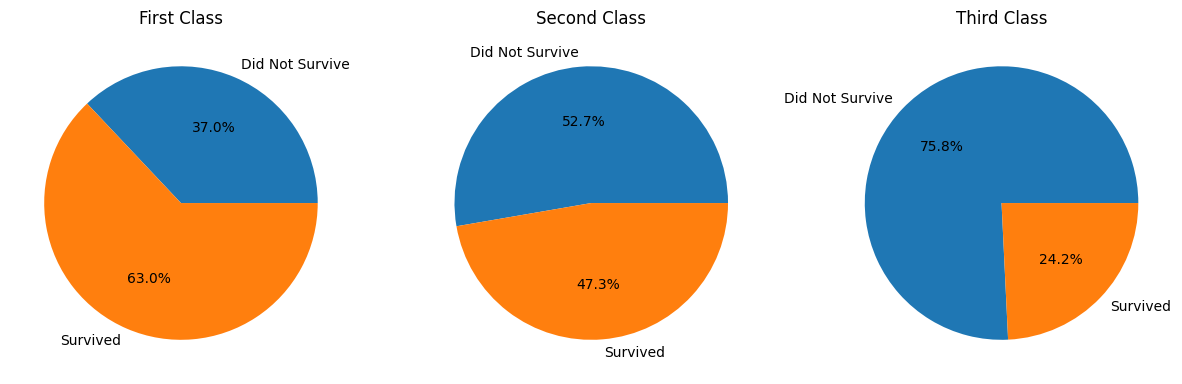

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15,5)) #-- 1 row, 3 columns, 15x5 (WidthxHeight) => so each one will be 5x5. --#
#-- First Class (Pclass = 1). --#
axes[0].pie(survival_by_class.loc[1], labels=['Did Not Survive', 'Survived'],autopct='%1.1f%%')
#-- EXPLAINATION: The .iloc[1] (location by label) means it will take data (number of people survived and not survived) of the first index. --#
#-- Similarly for the second and last one--#
axes[0].set_title('First Class')
#-- Second Class (Pclass = 2). --#
axes[1].pie(survival_by_class.loc[2], labels=['Did Not Survive', 'Survived'],autopct='%1.1f%%')
axes[1].set_title('Second Class')
#-- Third Class (Pclass = 3). --#
axes[2].pie(survival_by_class.loc[3], labels=['Did Not Survive', 'Survived'],autopct='%1.1f%%')
axes[2].set_title('Third Class')

## 2.2 Age Distribution. ##
Purpose: Overview of the age range represented in the dataset and identifies the age groups that make up the majority of passengers.

In [23]:
#-- Import Python Library. --#
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

<Figure size 800x500 with 0 Axes>

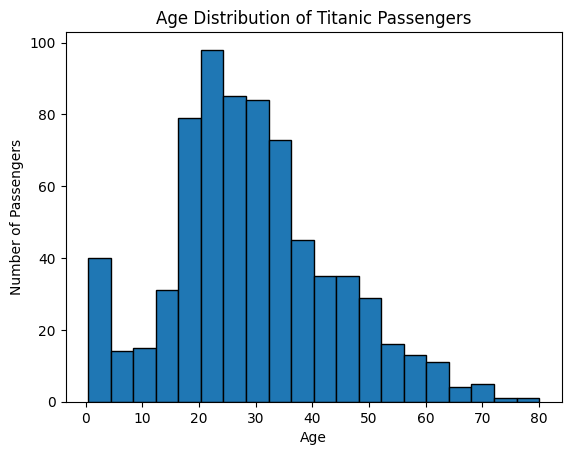

In [29]:
plt.hist(titanic['Age'].dropna(),bins=20,edgecolor='black')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## 2.3 Age and Survival. ##
Purpose: Investigate whether age affected survival outcomes.

In [31]:
#-- Import Python Library. --#
import matplotlib.pyplot as plt
not_survived = titanic[titanic['Survived'] == 0]['Age'].dropna()
survived = titanic[titanic['Survived'] == 1]['Age'].dropna()
not_survived

,Age
0,22.0
4,35.0
6,54.0
7,2.0
12,20.0
...,...
883,28.0
884,25.0
885,39.0
886,27.0


In [32]:
survived

,Age
1,38.0
2,26.0
3,35.0
8,27.0
9,14.0
...,...
875,15.0
879,56.0
880,25.0
887,19.0


/tmp/ipykernel_3575/1734130356.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([not_survived, survived],labels=['Did Not Survive','Survived'])


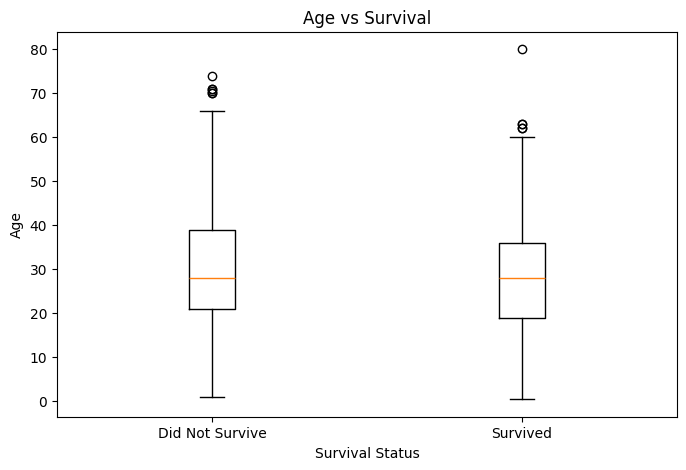

In [33]:
plt.figure(figsize=(8,5))
plt.boxplot([not_survived, survived],labels=['Did Not Survive','Survived'])
#-- Set title and label for x and y. --#
plt.title('Age vs Survival')
plt.xlabel('Survival Status')
plt.ylabel('Age')
#-- Display the graph
plt.show()